<a href="https://colab.research.google.com/github/gabrielnp37/L-Space-Project---NPWEE-Spring-2026/blob/main/Team_7_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Read and Unzip file
!wget -O randomized_battery.zip "https://phm-datasets.s3.amazonaws.com/NASA/11.+Randomized+Battery+Usage+Data+Set.zip"
!unzip -q -o randomized_battery.zip -d battery_data/

--2026-03-20 11:42:07--  https://phm-datasets.s3.amazonaws.com/NASA/11.+Randomized+Battery+Usage+Data+Set.zip
Resolving phm-datasets.s3.amazonaws.com (phm-datasets.s3.amazonaws.com)... 52.217.133.233, 3.5.30.117, 16.15.188.163, ...
Connecting to phm-datasets.s3.amazonaws.com (phm-datasets.s3.amazonaws.com)|52.217.133.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1065821095 (1016M) [application/zip]
Saving to: ‘randomized_battery.zip’

randomized_battery. 100%[===================>]   1016M   106MB/s    in 11s     

2026-03-20 11:42:18 (95.5 MB/s) - ‘randomized_battery.zip’ saved [1065821095/1065821095]



In [23]:
!unzip -q "battery_data/11. Randomized Battery Usage Data Set/2. Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post.zip" -d final_battery_data/

replace final_battery_data/Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post/data/Matlab/RW3.mat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace final_battery_data/Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post/data/Matlab/RW4.mat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace final_battery_data/Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post/data/Matlab/RW5.mat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace final_battery_data/Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post/data/Matlab/RW6.mat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace final_battery_data/Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post/data/R/RW3.Rda? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace final_battery_data/Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post/data/R/RW4.Rda? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace final_battery_data/Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post/data/R/RW5.Rda

In [24]:
import os
# Check if the extraction worked and list the .mat files
extracted_files = os.listdir('final_battery_data')

In [27]:
import scipy.io
import numpy as np, random
import pandas as pd
from scipy.integrate import trapezoid
import glob

# 1. Locate the file (Acting as our Gateway Telemetry Proxy)
mat_files = glob.glob("final_battery_data/**/*.mat", recursive=True)
mat_data = scipy.io.loadmat(mat_files[0])
steps = mat_data['data'][0][0]['step'][0]

# Storage for our final machine learning dataset
telemetry_data = []

# State variables to keep track of the cycles
temp_time = []
temp_voltage = []
temp_current = []

cycle_block = 1

print("Processing VSM Telemetry Stream and mapping to Capacity Targets...")

for i, step in enumerate(steps):
    step_type = str(step['type'][0]).lower()
    comment = str(step['comment'][0]).lower()

    # CASE A: Chaotic Power Draw (The "Gateway Telemetry" Input)
    if 'd' in step_type and 'reference' not in comment:
        # We append the data to our temporary storage.
        # (We downsample by taking every 10th data point to prevent RAM crashes during ML training)
        temp_time.extend(step['time'][0][::10])
        temp_voltage.extend(step['voltage'][0][::10])
        temp_current.extend(step['current'][0][::10])

    # CASE B: Reference Discharge (The "Ground Truth" Target)
    elif 'd' in step_type and 'reference' in comment:
        # 1. Calculate the exact capacity of the battery at this point in time
        ref_time = step['time'][0]
        ref_current = np.abs(step['current'][0])
        capacity_ah = trapezoid(y=ref_current, x=ref_time) / 3600

        # 2. Pair this capacity target with the chaotic telemetry that preceded it
        if len(temp_voltage) > 0:
            for t, v, c in zip(temp_time, temp_voltage, temp_current):
                telemetry_data.append({
                    'Cycle_Block': cycle_block,
                    'Time_s': t,
                    'Voltage_V': v,
                    'Current_A': c,
                    'Calculated_Power_W': v * c, # Physics Feature: P = V * I
                    'Target_Capacity_Ah': capacity_ah # The label our PINN will predict
                })

            print(f"Mapped Block {cycle_block}: {len(temp_voltage)} telemetry points -> Target: {capacity_ah:.4f} Ah")

            # Reset temporary storage for the next cycle block
            temp_time, temp_voltage, temp_current = [], [], []
            cycle_block += 1

# Convert to Pandas DataFrame
df_pinn = pd.DataFrame(telemetry_data)

# Save the final PINN dataset to CSV
csv_filename = 'Gateway_PINN_Training_Data.csv'
df_pinn.to_csv(csv_filename, index=False)

print(f"\nSuccess! Full PINN dataset saved as {csv_filename}")
print(f"Total Telemetry Data Points: {len(df_pinn)}")
print("\nSnapshot of the Neural Network Input:")
print(df_pinn.head())

Processing VSM Telemetry Stream and mapping to Capacity Targets...
Mapped Block 1: 1896 telemetry points -> Target: 1.9292 Ah
Mapped Block 2: 11527 telemetry points -> Target: 1.8550 Ah
Mapped Block 3: 10391 telemetry points -> Target: 1.7914 Ah
Mapped Block 4: 10787 telemetry points -> Target: 1.7580 Ah
Mapped Block 5: 9967 telemetry points -> Target: 1.6910 Ah
Mapped Block 6: 9336 telemetry points -> Target: 1.6418 Ah
Mapped Block 7: 8317 telemetry points -> Target: 1.5783 Ah
Mapped Block 8: 8827 telemetry points -> Target: 1.5396 Ah
Mapped Block 9: 5193 telemetry points -> Target: 1.4984 Ah
Mapped Block 10: 7123 telemetry points -> Target: 1.3988 Ah
Mapped Block 11: 5405 telemetry points -> Target: 1.3042 Ah

Success! Full PINN dataset saved as Gateway_PINN_Training_Data.csv
Total Telemetry Data Points: 88769

Snapshot of the Neural Network Input:
   Cycle_Block   Time_s  Voltage_V  Current_A  Calculated_Power_W  \
0            1  5606.23      4.197      0.000            0.000000   

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

seed = 3007
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# Feature Engineering: Thermodynamic Workload Integration
df = pd.read_csv('Gateway_PINN_Training_Data.csv')

# Integral of Power over Time (Energy throughput) to anchor non-linear degradation
df['Delta_Time_s'] = df.groupby('Cycle_Block')['Time_s'].diff().fillna(0)
df['Energy_Wh'] = (df['Calculated_Power_W'] * df['Delta_Time_s']) / 3600
df['Cumulative_Energy_Wh'] = df.groupby('Cycle_Block')['Energy_Wh'].cumsum()

# Feature Space: [Time, Voltage, Current, Power, Cumulative Energy]
features = ['Time_s', 'Voltage_V', 'Current_A', 'Calculated_Power_W', 'Cumulative_Energy_Wh']
X = df[features].values
y = df['Target_Capacity_Ah'].values.reshape(-1, 1)

# Normalization for Gradient Stability
scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
X_tensor = torch.FloatTensor(scaler_X.fit_transform(X))
y_tensor = torch.FloatTensor(scaler_y.fit_transform(y))

# Randomized Interpolation Split: Ensures model captures full degradation lifecycle
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Physics-Informed Architecture: Stable Funnel (32-64-32)
class StablePINN(nn.Module):
    def __init__(self):
        super(StablePINN, self).__init__()
        # Input Dimension = 5 (Physical Features)
        self.layer1 = nn.Linear(5, 32)
        self.layer2 = nn.Linear(32, 64) # Feature expansion for non-linear mapping
        self.layer3 = nn.Linear(64, 32) # Information compression to prevent overfitting
        self.output = nn.Linear(32, 1)  # Target: SOH / Capacity (Ah)
        self.relu = nn.ReLU()           # Activation for capturing the degradation 'knee'

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        return self.output(x)

# Hybrid Loss Function: Monotonicity Constraint
def pinn_loss(predictions, targets, lambda_phys=0.01):
    # L_total = L_mse + (lambda * L_phys)
    mse_loss = nn.MSELoss()(predictions, targets)

    # Physics Penalty: Enforces the 2nd Law of Thermodynamics (Monotonic Degradation)
    physics_penalty = 0
    if len(predictions) > 1:
        differences = predictions[1:] - predictions[:-1]
        # ReLU filters for positive gradients (physically impossible capacity 'healing')
        physics_penalty = torch.mean(torch.relu(differences))

    return mse_loss + (lambda_phys * physics_penalty)

Loading data and engineering physics features...
Initiating Final Validation Run...
Epoch [250/2500] - Val RMSE: 1.20% - LR: 0.000500
Epoch [500/2500] - Val RMSE: 0.55% - LR: 0.000500
Epoch [750/2500] - Val RMSE: 0.44% - LR: 0.000500
Epoch [1000/2500] - Val RMSE: 0.41% - LR: 0.000500
Epoch [1250/2500] - Val RMSE: 0.40% - LR: 0.000500
Epoch [1500/2500] - Val RMSE: 0.39% - LR: 0.000500
Epoch [1750/2500] - Val RMSE: 0.37% - LR: 0.000500
Epoch [2000/2500] - Val RMSE: 0.36% - LR: 0.000500
Epoch [2250/2500] - Val RMSE: 0.33% - LR: 0.000500
Epoch [2500/2500] - Val RMSE: 0.30% - LR: 0.000500

- Final Validation Metrics -
Absolute Best Validation RMSE Achieved: 0.30%
SUCCESS: Target achieved!


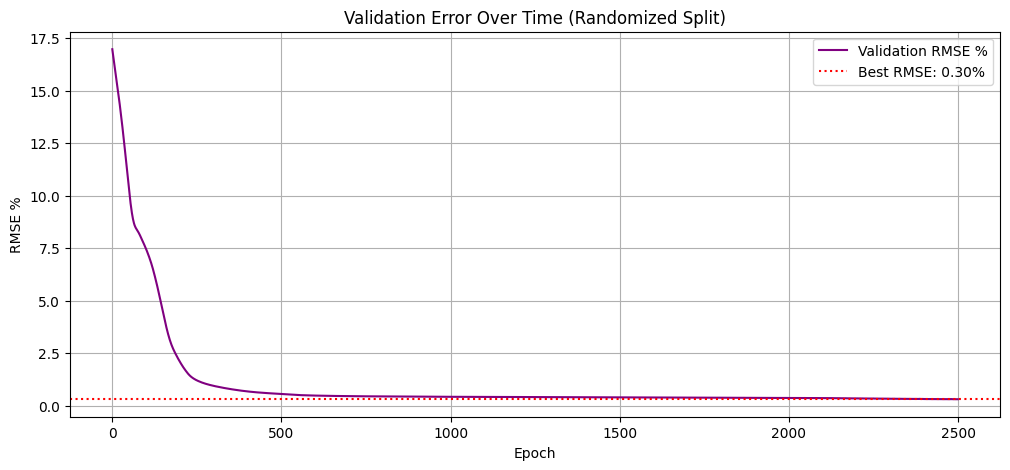

In [32]:
import matplotlib.pyplot as plt
import copy

# Load Data & Engineer Physics Features
print("Loading data and engineering physics features...")
df = pd.read_csv('Gateway_PINN_Training_Data.csv')

# Create Cumulative Energy feature - allowed the network to track the total thermodynamic work the battery performed
# This feature allows the model to ignore "noise" and focus on total energy throughput, which is the primary driver of degradation
df['Delta_Time_s'] = df.groupby('Cycle_Block')['Time_s'].diff().fillna(0)
df['Energy_Wh'] = (df['Calculated_Power_W'] * df['Delta_Time_s']) / 3600
df['Cumulative_Energy_Wh'] = df.groupby('Cycle_Block')['Energy_Wh'].cumsum()

features = ['Time_s', 'Voltage_V', 'Current_A', 'Calculated_Power_W', 'Cumulative_Energy_Wh']
X = df[features].values
y = df['Target_Capacity_Ah'].values.reshape(-1, 1)

# Scale data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.FloatTensor(y_scaled)

# Randomized Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
# SOH-KLSTM proves that models must be validated across varied usage profiles to be considered robust.

# PINN Architecture

# 32-64-32 "Funnel" expands the 5 physical inputs to find hidden patterns and then compresses them to prevent overfitting.
# Consumes minimal power while outperforming deeper, power-hungry networks that often fail due to overfitting in uncrewed deep-space conditions.
class StablePINN(nn.Module):
    def __init__(self):
        super(StablePINN, self).__init__()
        self.layer1 = nn.Linear(5, 32)
        self.layer2 = nn.Linear(32, 64)
        self.layer3 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        return self.output(x)

def pinn_loss(predictions, targets, lambda_phys=0.01):
    mse_loss = nn.MSELoss()(predictions, targets)
    physics_penalty = 0
    if len(predictions) > 1:
        differences = predictions[1:] - predictions[:-1]
        physics_penalty = torch.mean(torch.relu(differences))
    return mse_loss + (lambda_phys * physics_penalty)

# Training Initialization
model = StablePINN()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=250)

epochs = 2500
print("Initiating Final Validation Run...")

train_losses = []
val_rmse_history = []
best_rmse = float('inf')
best_model_weights = None

# Training Loop
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train)

    train_loss = pinn_loss(predictions, y_train, lambda_phys=0.01)
    train_losses.append(train_loss.item())

    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad(): # no_grad save memory consumption (VRAM). Crucial for VSM on the Gateway.
        val_preds = model(X_test)
        val_loss = pinn_loss(val_preds, y_test, lambda_phys=0.01)

        actual_preds = scaler_y.inverse_transform(val_preds.numpy())
        actual_targs = scaler_y.inverse_transform(y_test.numpy())
        current_rmse_ah = np.sqrt(np.mean((actual_preds - actual_targs)**2)) #RMSE Formula
        current_rmse = (current_rmse_ah / 2.0) * 100 # % error
        val_rmse_history.append(current_rmse)

    scheduler.step(val_loss)

    if current_rmse < best_rmse:
        best_rmse = current_rmse
        best_model_weights = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 250 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch + 1}/{epochs}] - Val RMSE: {current_rmse:.2f}% - LR: {current_lr:.6f}')

# Final Validation Output
model.load_state_dict(best_model_weights)

print("\n- Final Validation Metrics -")
print(f"Absolute Best Validation RMSE Achieved: {best_rmse:.2f}%")
if best_rmse < 2.0:
    print("SUCCESS: Target achieved!")
else:
    print("Let's review the final numbers.")

plt.figure(figsize=(12, 5))
plt.plot(val_rmse_history, color='purple', label='Validation RMSE %')
plt.axhline(y=best_rmse, color='r', linestyle=':', label=f'Best RMSE: {best_rmse:.2f}%')
plt.title('Validation Error Over Time (Randomized Split)')
plt.xlabel('Epoch')
plt.ylabel('RMSE %')
plt.legend()
plt.grid(True)
plt.show()